### Problem 1 - Approximation of integrals I

Consider the integral

$$I = \int_{\sqrt{2}}^{\infty}\frac{1}{x + x^{\sqrt{2}}}dx$$

a) Trying to find the value of $I$ using numerical integration.

In [1]:
from scipy import integrate
import numpy as np

function = lambda x: 1/(x + x**np.sqrt(2))

lower_limit = np.sqrt(2)
upper_limit = np.inf

result, error = integrate.quad(function, lower_limit, upper_limit)

print(f"Numerical integration: {result}")
print(f"Estimated error: {error}")

Numerical integration: 1.5063322633843683
Estimated error: 2.0084245377915977e-10


b) Computing the sequence defined by $x_1 = 23, x_2 = 66$ and

$$x_n = 3x_{n-1}+5x_{n-2} \mod{100}, \space n\geq 3,$$
and letting $u_n = x_n / 100$ for $n\geq 1$.

In [2]:
import numpy as np
x = np.zeros((20, 1))
x[0] = 23
x[1] = 66

for i in range(2, 20):
	x[i] = (3*x[i-1] + 5*x[i-2])%100

for j in range(len(x)):
	print(f"u_{j+1} = {x[j][0]/100}")

u_1 = 0.23
u_2 = 0.66
u_3 = 0.13
u_4 = 0.69
u_5 = 0.72
u_6 = 0.61
u_7 = 0.43
u_8 = 0.34
u_9 = 0.17
u_10 = 0.21
u_11 = 0.48
u_12 = 0.49
u_13 = 0.87
u_14 = 0.06
u_15 = 0.53
u_16 = 0.89
u_17 = 0.32
u_18 = 0.41
u_19 = 0.83
u_20 = 0.54


d) Approximating transformed $I$ using the sequence above and another psuedorandom number generator.

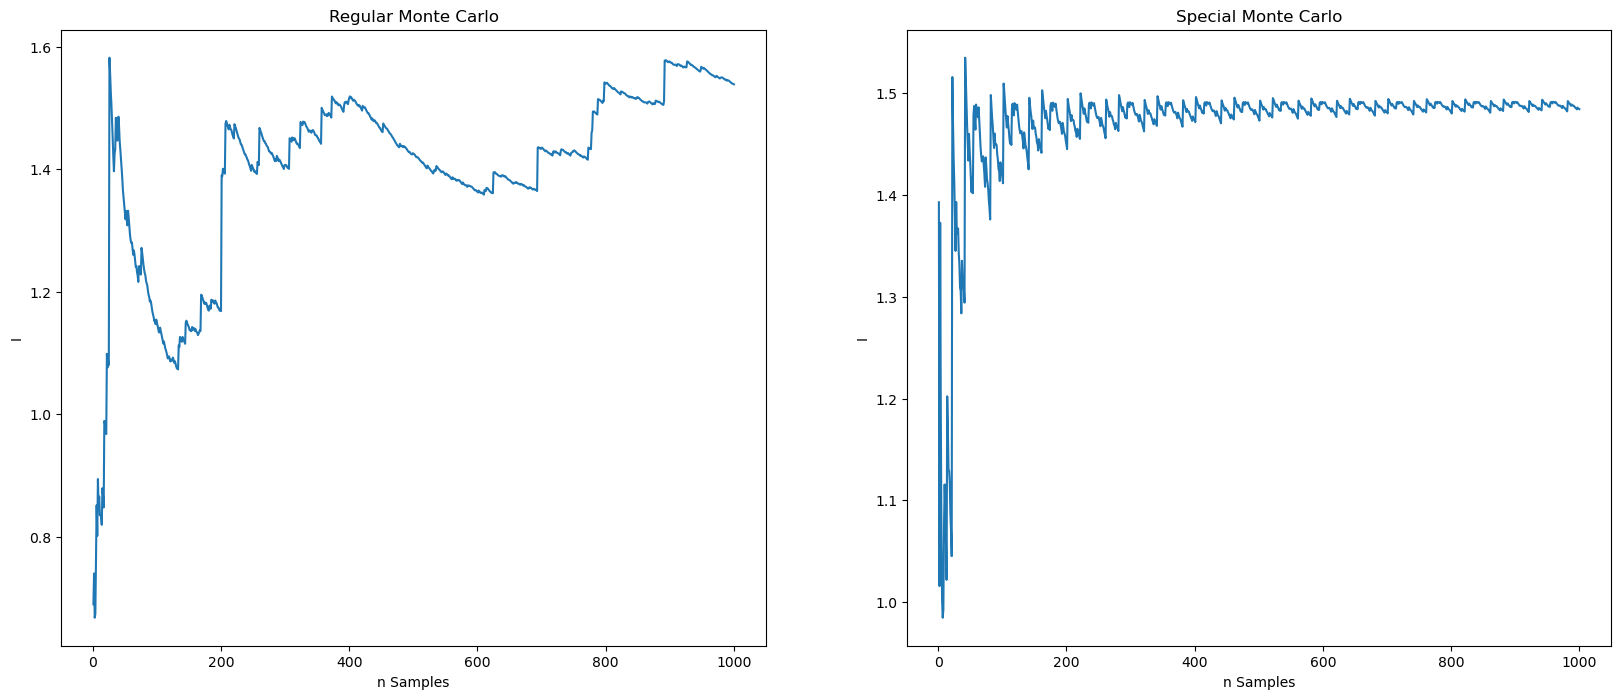

The regular Monte Carlo Integral Approximation: 1.5382917996450076
The special Monte Carlo Integral Approximation: 1.48411471708652


In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import random

def integrand(y):
	return 1/(y + y**(2-np.sqrt(2))*np.sqrt(2)**(np.sqrt(2)-1))

N = 1000

# Create the special random vector
x = np.zeros((N, 1))
x[0] = 23
x[1] = 66
for i in range(2, N):
	x[i] = (3*x[i-1] + 5*x[i-2])%100
x /= 100

# Perform the Integral Approximations
I = np.zeros((N, 1))
I_values = np.zeros((N, 1))
I_prime = np.zeros((N, 1))
I_prime_values = np.zeros((N, 1))
for n in range(N):
	I_values[n] = integrand(random.random())
	I[n] = np.sum(I_values)/(n + 1)
	I_prime_values[n] = integrand(x[n][0])
	I_prime[n] = np.sum(I_prime_values)/(n + 1)

plt.figure(1, [20, 8])

plt.subplot(1, 2, 1)
plt.plot(np.linspace(1, N, N), I)
plt.title("Regular Monte Carlo")
plt.xlabel("n Samples")
plt.ylabel("Approximation")

plt.subplot(1, 2, 2)
plt.plot(np.linspace(1, N, N), I_prime)
plt.title("Special Monte Carlo")
plt.xlabel("n Samples")
plt.ylabel("Approximation")

plt.show()

print(f"The regular Monte Carlo Integral Approximation: {I[-1][0]}")
print(f"The special Monte Carlo Integral Approximation: {I_prime[-1][0]}")